# Converting Images And Processing
#### Load Libraries

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from skimage import exposure
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage.io import imread
from pathlib import Path
import pandas as pd

#### Load Images And Create Dataset

In [13]:
source_path = Path('/home/matthew/Development/Education/1 Shiny Smart Heal/Processing/DFU/Patches/Analysis')

# Create dataset
p = Path(source_path).glob('**/*')
files = [x for x in p if x.is_file()]

datalist = []
for file in files:
    dataline = {}
    image = imread(file)
    dataline['image'] = image
    dataline['label'] = file.parent.name
    # Transform image to HOG
    feature, hog_image = hog(image, orientations=8, pixels_per_cell=(16, 16), cells_per_block=(1, 1),visualize=True,channel_axis=-1,block_norm='L2-Hys')
    dataline['data'] = feature
    dataline['hog'] = hog_image
    datalist.append(dataline)

dataset = pd.DataFrame(datalist)

#### Visualise One Of The Transformed Images

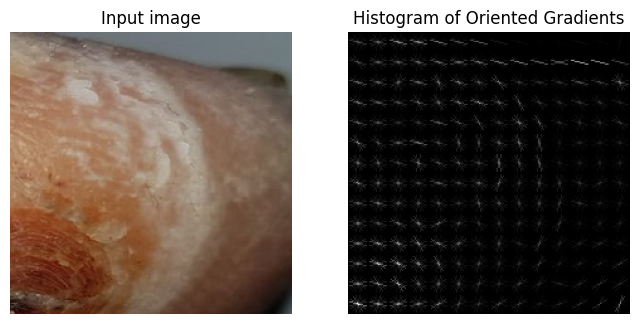

In [15]:
sample_image = dataset.iloc[1]['image']
sample_hog = dataset.iloc[1]['hog']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(sample_image, cmap=plt.cm.gray)
ax1.set_title('Input image')

# Rescale histogram for better display
hog_image_rescaled = exposure.rescale_intensity(sample_hog, in_range=(0, 10))

ax2.axis('off')
ax2.imshow(sample_hog, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')
plt.show()

#### Split Data And Scale

In [16]:
# Preprocess dataset
X = dataset['data']
y = dataset['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=9999)